In [2]:
import yaml

# Data to be written to the YAML file
data = {
    'train': 
    'C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/mold_dataset/train/images',  # Path to the training images
    'val': 
    'C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/mold_dataset/val/images',      # Path to the validation images
    'nc': 1,                             # Number of classes
    'names': ['Fungi']  # Names of the classes
}

# Specify the name of the YAML file
yaml_file_path = 'dataset_1.yaml'

# Write data to the YAML file
with open(yaml_file_path, 'w') as file:
    yaml.dump(data, file, default_flow_style=False)

print(f'YAML file created :/ {yaml_file_path}')

YAML file created :/ dataset_1.yaml


# Exploratory Data Analysis for Early Detection of Mold Growth

### Data to be written to the YAML file

## 1. Data Distribution

## 1a. Image Distribution Visualization 

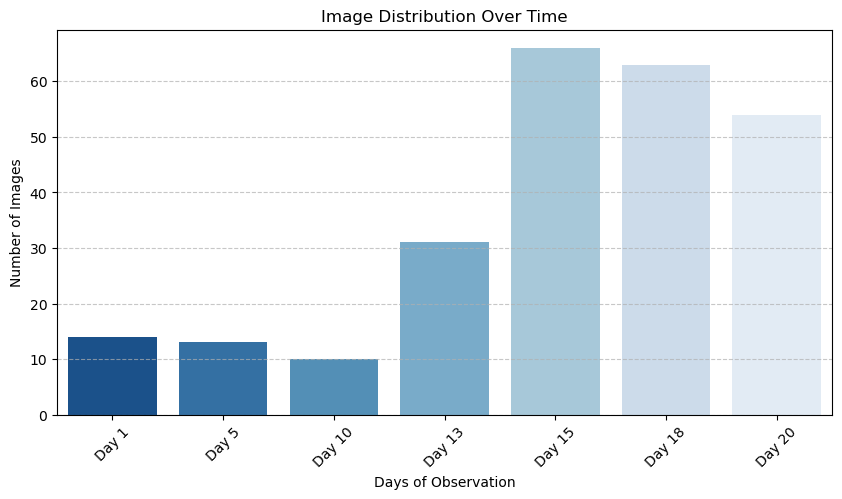

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset: Number of images collected on different days
image_counts = {
    "Day 1": 14,
    "Day 5": 13,
    "Day 10": 10,
    "Day 13": 31,
    "Day 15": 66,
    "Day 18": 63,
    "Day 20": 54
}

# Create a bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette="Blues_r")

# Add labels and title
plt.xlabel("Days of Observation")
plt.ylabel("Number of Images")
plt.title("Image Distribution Over Time")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show plot
plt.show()


## 1b. Basic Data Augmentation (Rotation, flipping, contrast adjustment) 

In [1]:
import cv2
import numpy as np
import os
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation functions
datagen = ImageDataGenerator(
    rotation_range=20,  # Rotate up to 20 degrees
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],  # Adjust brightness
    zoom_range=0.2,  # Zoom in
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Path to input dataset
input_folder = "C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/EDA/Day1_5_10_Original"
output_folder = "C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/EDA/Day1_5_10_Augmented"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Apply augmentation
for filename in os.listdir(input_folder):
    img_path = os.path.join(input_folder, filename)
    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img = np.expand_dims(img, axis=0)  # Add batch dimension

        # Generate augmented images
        i = 0
        for batch in datagen.flow(img, batch_size=1, save_to_dir=output_folder, save_prefix="aug", save_format="jpg"):
            i += 1
            if i >= 5:  # Generate 5 variations per image
                break

print("Augmentation complete. New images saved in:", output_folder)


Augmentation complete. New images saved in: C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/EDA/Day1_5_10_Augmented


# 2: Color & Texture Analysis for Early Mold Detection

## 2a. Color Histogram (RGB & HSV Channels) 

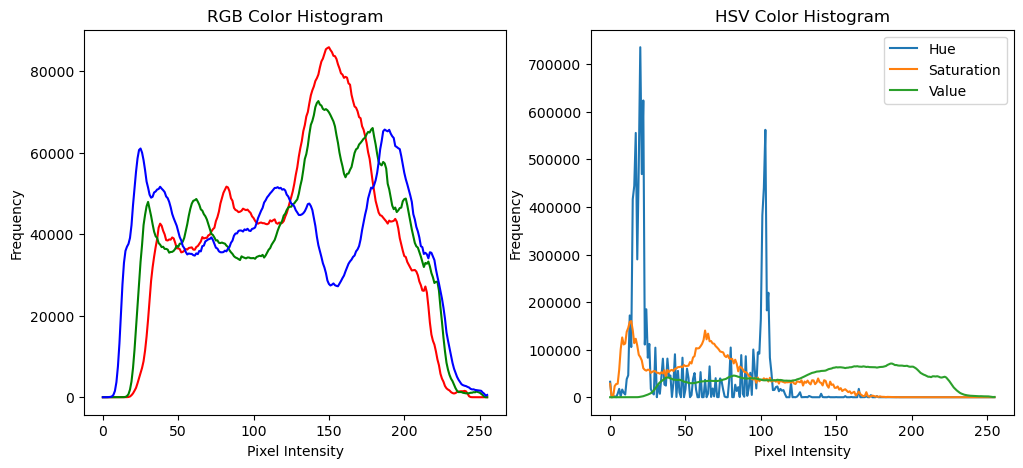

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Function to plot color histograms
def plot_color_histograms(image_path):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define color channels
    colors = ("red", "green", "blue")
    hsv_labels = ("Hue", "Saturation", "Value")

    plt.figure(figsize=(12, 5))

    # RGB Histogram
    plt.subplot(1, 2, 1)
    for i, color in enumerate(colors):
        hist = cv2.calcHist([image_rgb], [i], None, [256], [0, 256])
        plt.plot(hist, color=color)
    plt.title("RGB Color Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    # HSV Histogram
    plt.subplot(1, 2, 2)
    for i, label in enumerate(hsv_labels):
        hist = cv2.calcHist([image_hsv], [i], None, [256], [0, 256])
        plt.plot(hist, label=label)
    plt.title("HSV Color Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

# Example Usage
image_path = "C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/EDA/Balanced Dataset/IMG_20250124_183723.jpg"  # Replace with your image path
plot_color_histograms(image_path)


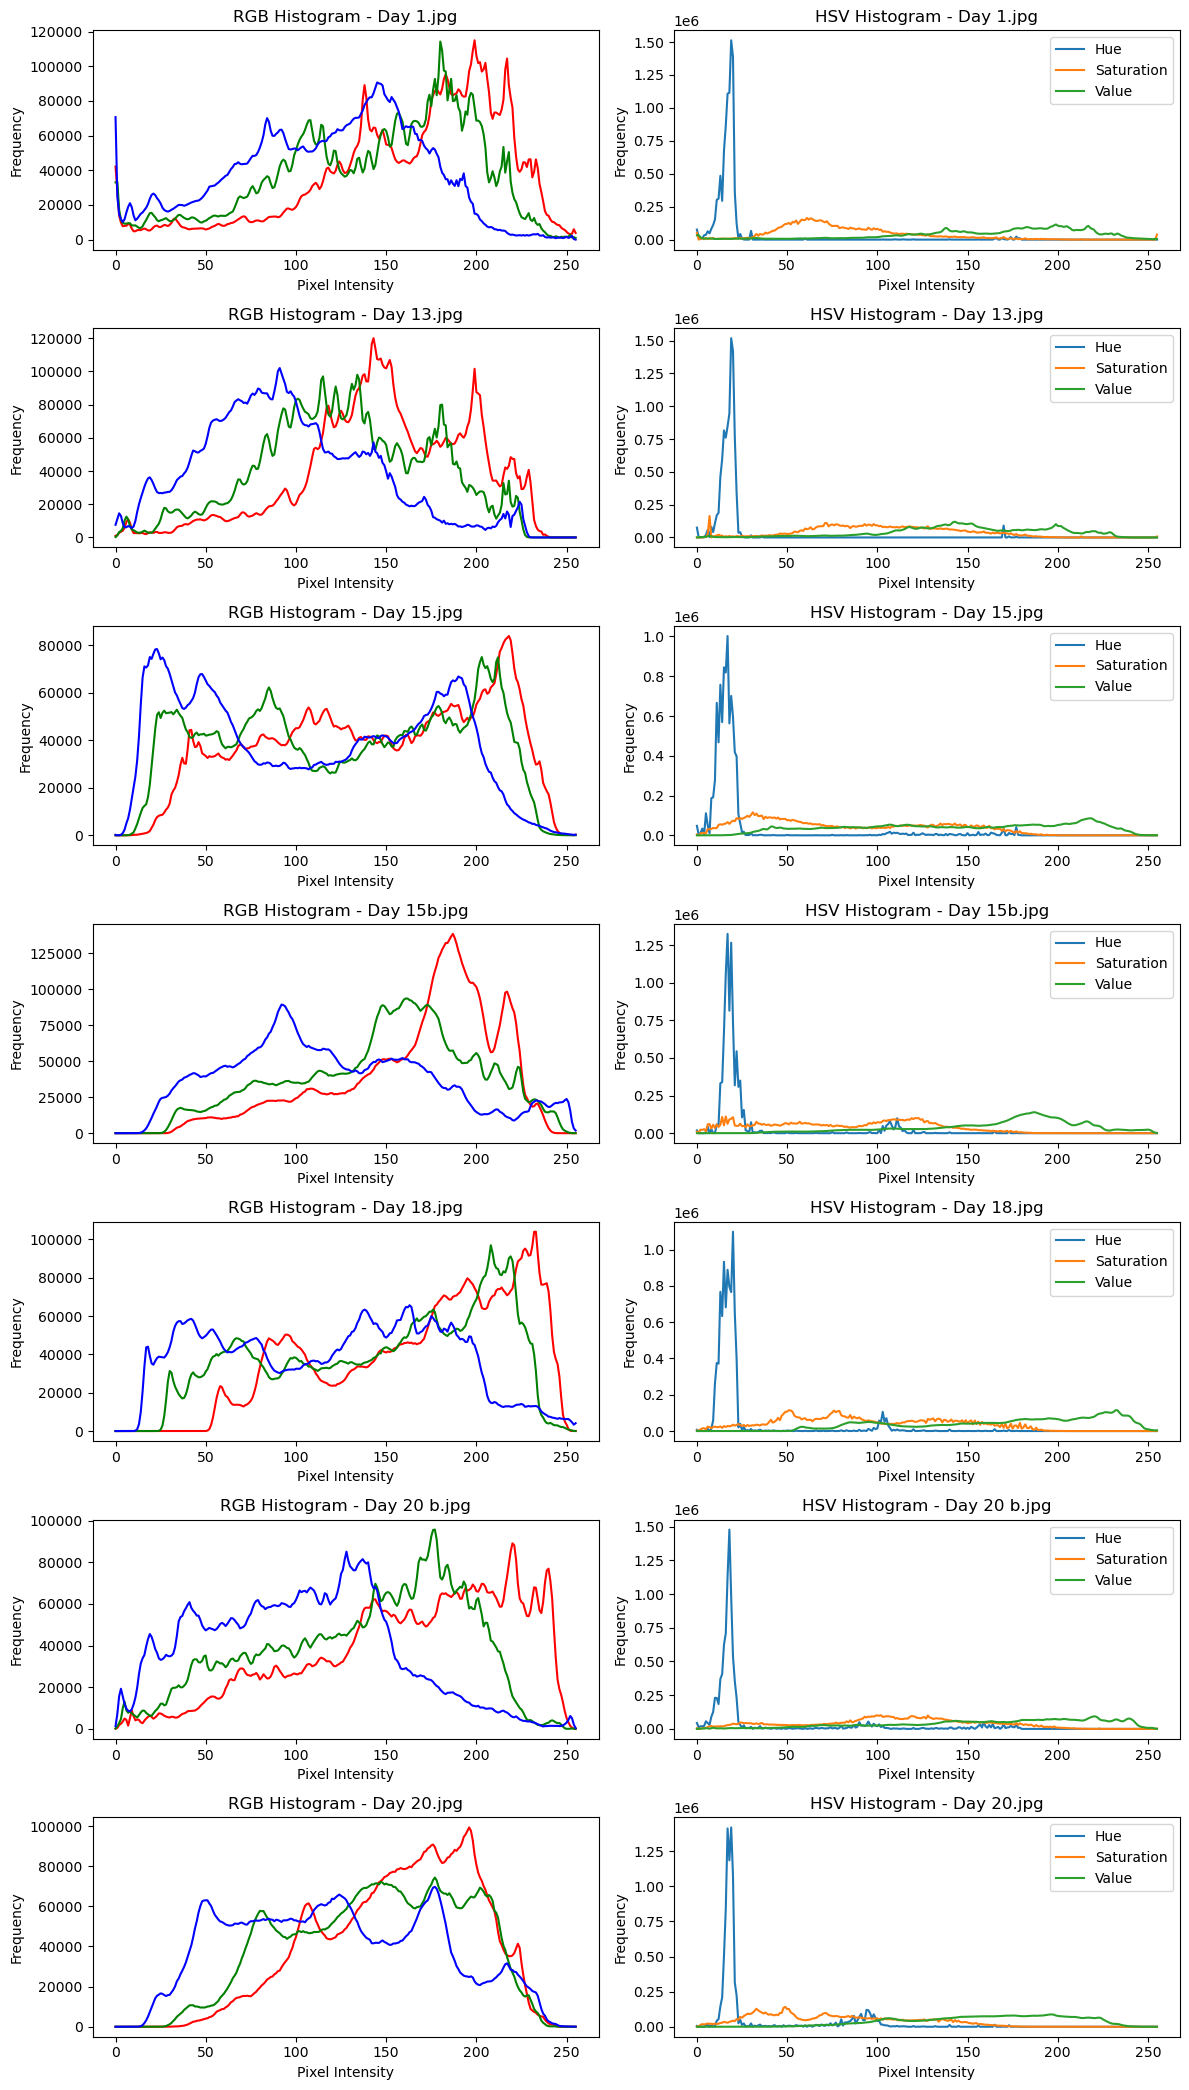

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Load multiple images
image_paths = sorted(glob.glob("C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/EDA/color histogram/*.jpg"))[:8]  # Adjust path to actual dataset
if not image_paths:
    print("No images found! Check dataset path.")
    exit()

# Define colors and labels
colors = ('red', 'green', 'blue')
hsv_labels = ('Hue', 'Saturation', 'Value')

# Set up subplots
fig, axes = plt.subplots(len(image_paths), 2, figsize=(12, len(image_paths) * 3))

for idx, image_path in enumerate(image_paths):
    image = cv2.imread(image_path)
    
    if image is None:
        print(f"Could not read {image_path}")
        continue
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # RGB Histogram
    ax = axes[idx, 0]
    for i, color in enumerate(colors):
        hist = cv2.calcHist([image_rgb], [i], None, [256], [0, 256])
        ax.plot(hist, color=color)
    ax.set_title(f"RGB Histogram - Day {os.path.basename(image_path)}")
    ax.set_xlabel("Pixel Intensity")
    ax.set_ylabel("Frequency")

    # HSV Histogram
    ax = axes[idx, 1]
    for i, label in enumerate(hsv_labels):
        hist = cv2.calcHist([image_hsv], [i], None, [256], [0, 256])
        ax.plot(hist, label=label)
    ax.set_title(f"HSV Histogram - Day {os.path.basename(image_path)}")
    ax.set_xlabel("Pixel Intensity")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()


In [8]:
pip install --user albumentations

  Obtaining dependency information for albumentations from https://files.pythonhosted.org/packages/4a/86/577b8ea4d0922e05911dc2cf48d8cb652a5a58eb456c4c3e06b076635292/albumentations-2.0.2-py3-none-any.whl.metadata
  Using cached albumentations-2.0.2-py3-none-any.whl.metadata (38 kB)
  Obtaining dependency information for pydantic>=2.9.2 from https://files.pythonhosted.org/packages/f4/3c/8cc1cc84deffa6e25d2d0c688ebb80635dfdbf1dbea3e30c541c8cf4d860/pydantic-2.10.6-py3-none-any.whl.metadata
  Using cached pydantic-2.10.6-py3-none-any.whl.metadata (30 kB)
  Obtaining dependency information for albucore==0.0.23 from https://files.pythonhosted.org/packages/3d/de/4d9298befa6ae0f21230378f55100dca364816e3734028ca2766f2eca263/albucore-0.0.23-py3-none-any.whl.metadata
  Using cached albucore-0.0.23-py3-none-any.whl.metadata (5.3 kB)
  Obtaining dependency information for opencv-python-headless>=4.9.0.80 from https://files.pythonhosted.org/packages/86/8a/69176a64335aed183529207ba8bc3d329c2999d852b4

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anaconda-cloud-auth 0.1.3 requires pydantic<2.0, but you have pydantic 2.10.6 which is incompatible.


C:\Users\Srikanth\AppData\Local\Temp\ipykernel_14032\2643351425.py:25: UserWarning: Argument 'var_limit' is not valid and will be ignored.
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3), # Add noise


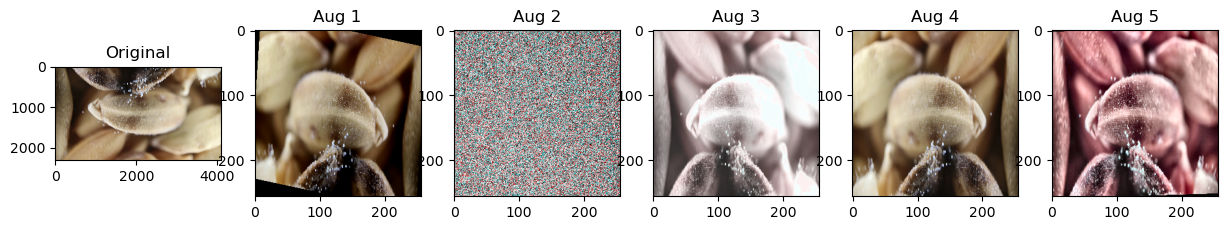

In [10]:
import cv2
import numpy as np
import albumentations as A
import random
import matplotlib.pyplot as plt

# Load an example image
image_path = "C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/IMG_20250113_065042.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Define augmentations
augmentations = A.Compose([
    # Geometric Transformations
    A.Rotate(limit=30, p=0.5),                 # Random rotation
    A.HorizontalFlip(p=0.5),                   # Horizontal flip
    A.VerticalFlip(p=0.5),                     # Vertical flip
    A.RandomCrop(height=200, width=200, p=0.5),# Cropping
    A.Resize(height=256, width=256),           # Resizing

    # Color & Intensity Transformations
    A.RandomBrightnessContrast(p=0.5),         # Adjust brightness & contrast
    A.HueSaturationValue(p=0.5),               # Change hue & saturation
    A.GaussianBlur(blur_limit=5, p=0.3),       # Apply blur
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3), # Add noise

    # Advanced Augmentations
    A.CLAHE(p=0.5),                            # Improve contrast
    A.ChannelShuffle(p=0.5),                   # Shuffle RGB channels
])

# Apply augmentations
augmented_images = [augmentations(image=image)["image"] for _ in range(5)]

# Display original and augmented images
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title("Original")
for i, aug_img in enumerate(augmented_images):
    axes[i+1].imshow(aug_img)
    axes[i+1].set_title(f"Aug {i+1}")
plt.show()
